In [157]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve

## Confusion Matrix

In [158]:
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None):
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    ax.xaxis.set_ticklabels(['False', 'True'])
    ax.yaxis.set_ticklabels(['False', 'True'])

## ROC-Curve

In [159]:
def plot_roc_curve(fper, tper, title="ROC Curve", ax=None):
    roc_auc = auc(fper, tper)
    ax.plot(fper, tper, color='red', label=f'ROC curve (area = {roc_auc:0.2f})')
    ax.plot([0, 1], [0, 1], color='green', linestyle='--', label='No Skill')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

## Logistic Regression Pipeline

In [160]:

def logistic_regression_pipeline(data, target_column='z-score calculated from 7. 8. and 9.', threshold=1, class_weights={0: 1, 1: 3}):
    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    
    # Erstellen der 'label' Spalte mit dem Schwellenwert
    data["label"] = np.where(data[target_column] > threshold, 1, 0)
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Logistische Regression trainieren
    log_reg = LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=0)
    log_reg.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(log_reg, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = log_reg.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)
    print("False-Negative Rate: ", 1 - cm[1][0] / (cm[1][0] + cm[1][1]))

    # Schritt 5: ROC-Kurve und AUC berechnen
    y_test_prob = log_reg.predict_proba(X_test)[:, 1]
    fper, tper, thresholds = roc_curve(y_test, y_test_prob)
    auc_score = roc_auc_score(y_test, y_test_prob)
    print(f"AUC score: {auc_score}")
   
    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, "Confusion Matrix: Logistische Regression", ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, "ROC Curve: Logistische Regression", ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()  # Optional: Verbessert das Layout
    plt.show()

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
0    41846
1    28154
Name: count, dtype: int64
y_test label
0    17775
1    12225
Name: count, dtype: int64
Cross-validation scores: [0.99371429 0.99314286 0.99614286 0.99385714 0.99542857 0.994
 0.99328571 0.99457143 0.99385714 0.99414286]
Mean CV score: 0.9942142857142857
Accuracy score:  0.9952666666666666
False-Negative Rate:  1.0
AUC score: 0.9999976714152997


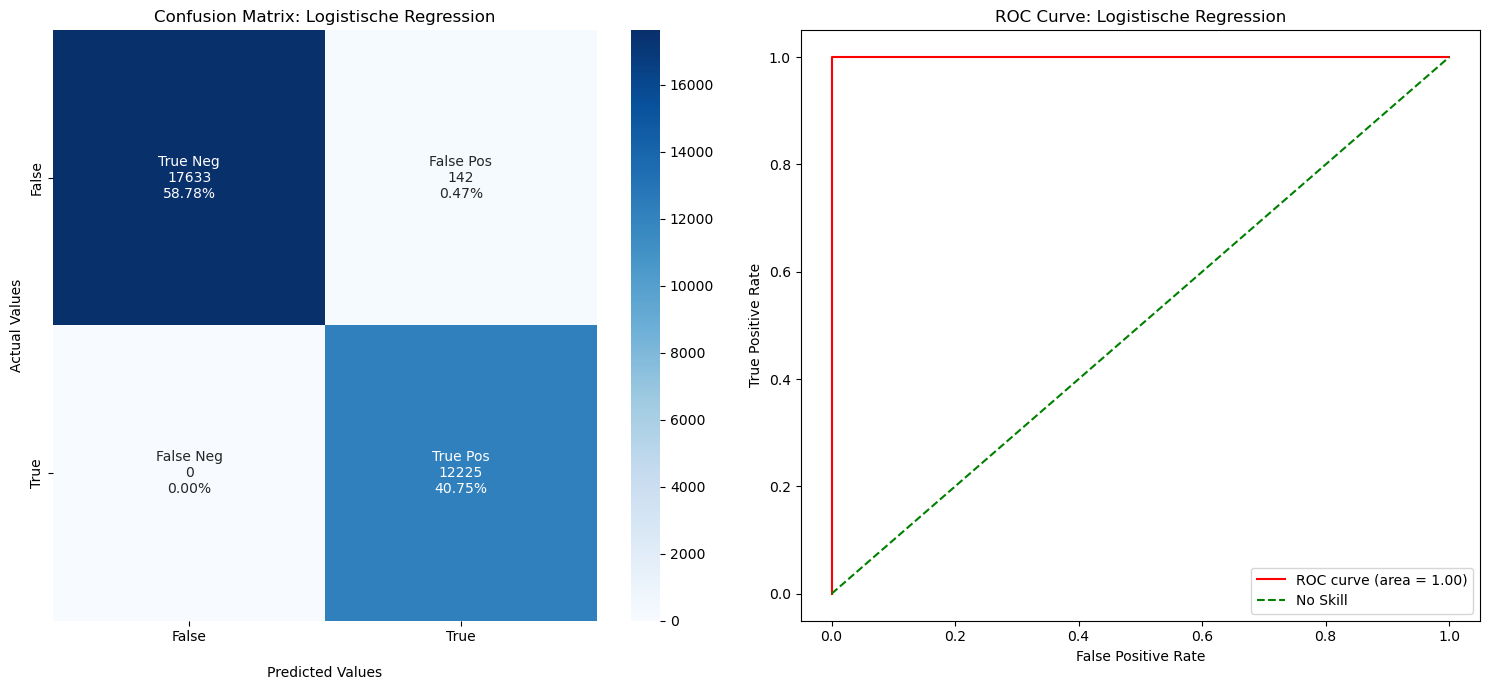

In [161]:
df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
logistic_regression_pipeline(df_sissiz_mono)

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
0    41846
1    28154
Name: count, dtype: int64
y_test label
0    17775
1    12225
Name: count, dtype: int64
Cross-validation scores: [0.99371429 0.99314286 0.99614286 0.99385714 0.99542857 0.994
 0.99328571 0.99457143 0.99385714 0.99414286]
Mean CV score: 0.9942142857142857
Accuracy score:  0.9952666666666666
False-Negative Rate:  1.0
AUC score: 0.9999976714152997


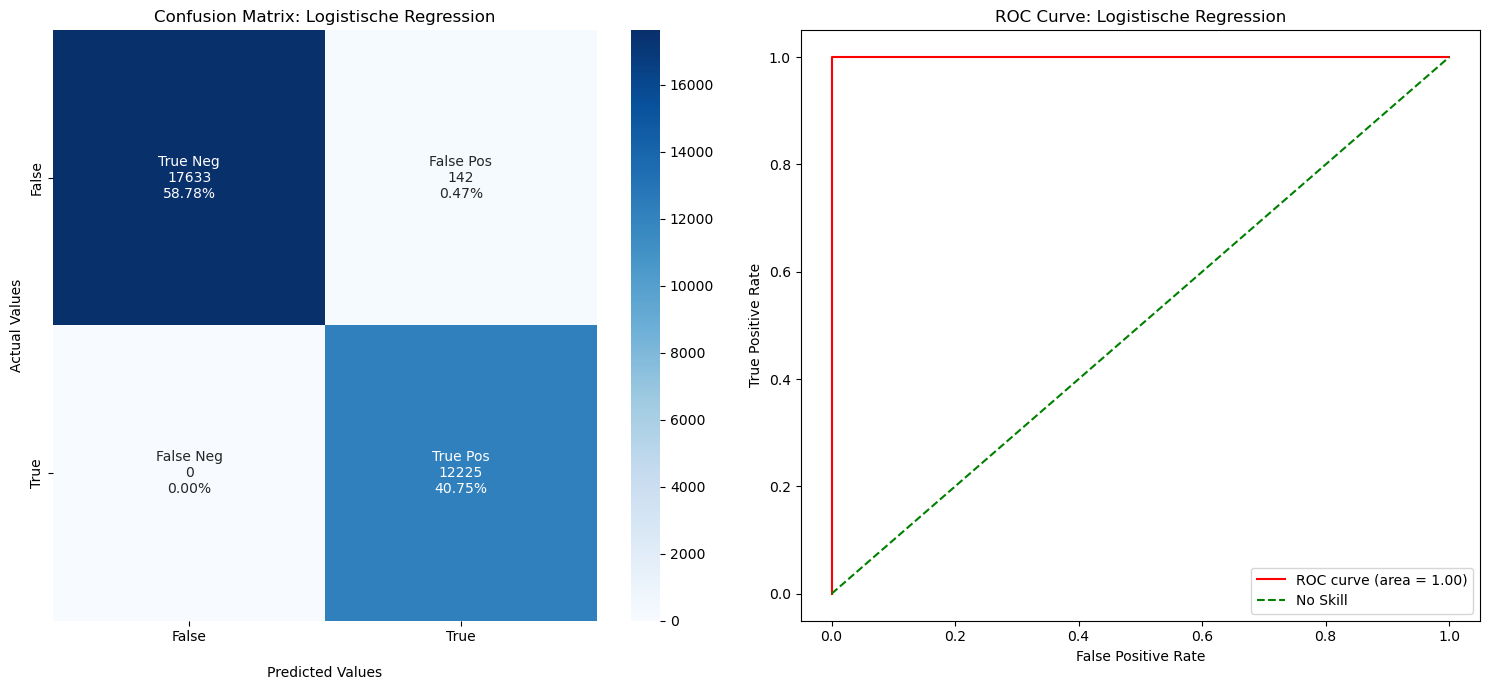

In [162]:
df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
logistic_regression_pipeline(df_sissiz_mono)

In [163]:
df_multiperm_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
logistic_regression_pipeline(df_multiperm_mono)

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
0    70000
Name: count, dtype: int64
y_test label
0    30000
Name: count, dtype: int64


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
0    68384
1     1616
Name: count, dtype: int64
y_test label
0    29306
1      694
Name: count, dtype: int64
Cross-validation scores: [0.99914286 0.999      0.99928571 0.99857143 0.99871429 0.99814286
 0.99814286 0.99985714 0.99928571 0.99885714]
Mean CV score: 0.9988999999999999
Accuracy score:  0.9992333333333333
False-Negative Rate:  1.0
AUC score: 0.9999992133093891


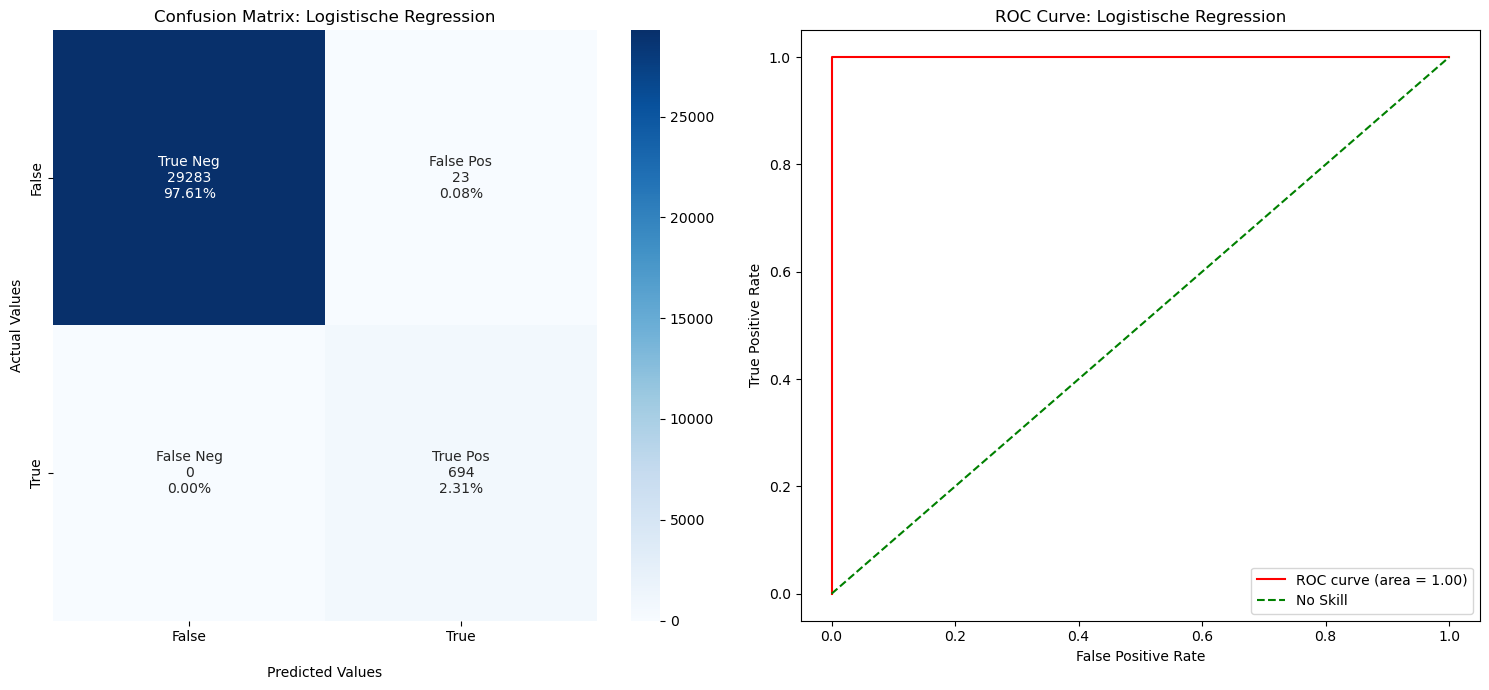

In [ ]:
df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
logistic_regression_pipeline(df_multiperm_di)

In [ ]:
df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))
logistic_regression_pipeline(df_aln_shuffle)

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
0    70000
Name: count, dtype: int64
y_test label
0    30000
Name: count, dtype: int64


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0